- 리뷰 및 제품 데이터프레임 로드

In [ ]:
import pandas as pd
bot = pd.read_csv('[0326]통합_챗봇api분석_정제.csv')
제품df = pd.read_csv('[0325]통합_제품DF.csv')

In [ ]:
bot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203549 entries, 0 to 203548
Data columns (total 11 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   상품ID    203549 non-null  int64  
 1   브랜드     203549 non-null  object 
 2   리뷰텍스트   203549 non-null  object 
 3   별점      203549 non-null  float64
 4   날짜      203549 non-null  object 
 5   리뷰유형    203549 non-null  object 
 6   감성점수    203549 non-null  int64  
 7   품질      203549 non-null  object 
 8   구성/가성비  203549 non-null  object 
 9   배송      203549 non-null  object 
 10  감성분류    203549 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 17.1+ MB


In [ ]:
제품df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   상품ID         976 non-null    int64  
 1   브랜드          976 non-null    object 
 2   순위           976 non-null    int64  
 3   분류           976 non-null    object 
 4   상품명          976 non-null    object 
 5   할인율          976 non-null    float64
 6   할인가          976 non-null    int64  
 7   총용량(g)       976 non-null    int64  
 8   단위가격(100g)   976 non-null    int64  
 9   리뷰수          976 non-null    float64
 10  평균별점         976 non-null    float64
 11  긍정리뷰비율       976 non-null    float64
 12  부정리뷰비율       976 non-null    float64
 13  품질언급비율       976 non-null    float64
 14  가성비언급비율      976 non-null    float64
 15  배송언급비율       976 non-null    float64
 16  저평점비율        976 non-null    float64
 17  최근 30일 리뷰비율  976 non-null    float64
 18  품질(긍정)       965 non-null    object 
 19  품질(부정)  

## 순반응 파생변수 생성

In [ ]:
# 상품ID 타입 통일
bot['상품ID'] = bot['상품ID'].astype(int)

# 순반응 지표 생성
for category, pos_col, neg_col, result_col in [
    ('품질',     '품질(긍정)',      '품질(부정)',      '품질순반응'),
    ('구성/가성비', '구성/가성비(긍정)', '구성/가성비(부정)', '가성비순반응'),
    ('배송',     '배송(긍정)',      '배송(부정)',      '배송순반응'),
]:
    valid = bot[bot[category] != '키워드 없음']

    pos_sum = (valid[valid['감성분류'] == '긍정']
               .groupby('상품ID')[category]
               .count()
               .rename('pos'))

    neg_sum = (valid[valid['감성분류'] == '부정']
               .groupby('상품ID')[category]
               .count()
               .rename('neg'))

    net = (pos_sum.subtract(neg_sum, fill_value=0)).rename(result_col)

    제품df = 제품df.merge(net, on='상품ID', how='left')
    제품df[result_col] = 제품df[result_col].fillna(0).astype(int)

print(제품df[['상품ID', '품질순반응', '가성비순반응', '배송순반응']].head())

          상품ID  품질순반응  가성비순반응  배송순반응
0  12274376800    -52       0    -64
1  12274518551    -16       2     -4
2  12274488227    -77     -22    -34
3  12274562713    229     174    107
4  12274500294     81      68     64


In [ ]:
# 순반응 지표 포함한 제품 데이터프레임 - 제품df1
제품df1 = 제품df.copy()

## 1. 별점 분포와 감성점수 분포 비교

In [ ]:
# [한글폰트 설치 - Colab]
import pandas as pd
import numpy as np

# Install Korean font
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# Configure Matplotlib to use NanumGothic
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # To prevent breaking minus sign

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 6 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (4,147 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and direc

In [ ]:
곰곰챗봇 = pd.read_csv('[0325]곰곰_챗봇api분석_정제.csv', encoding = 'UTF-8')

In [ ]:
곰곰챗봇['감성점수'].value_counts()

,count
감성점수,
4,55865
1,34117
5,30894
2,20678
3,14190


In [ ]:
곰곰챗봇 = 곰곰챗봇[곰곰챗봇['감성점수'] != '키워드 없음']

In [ ]:
곰곰챗봇['감성점수'] = 곰곰챗봇['감성점수'].astype(float).astype(int)

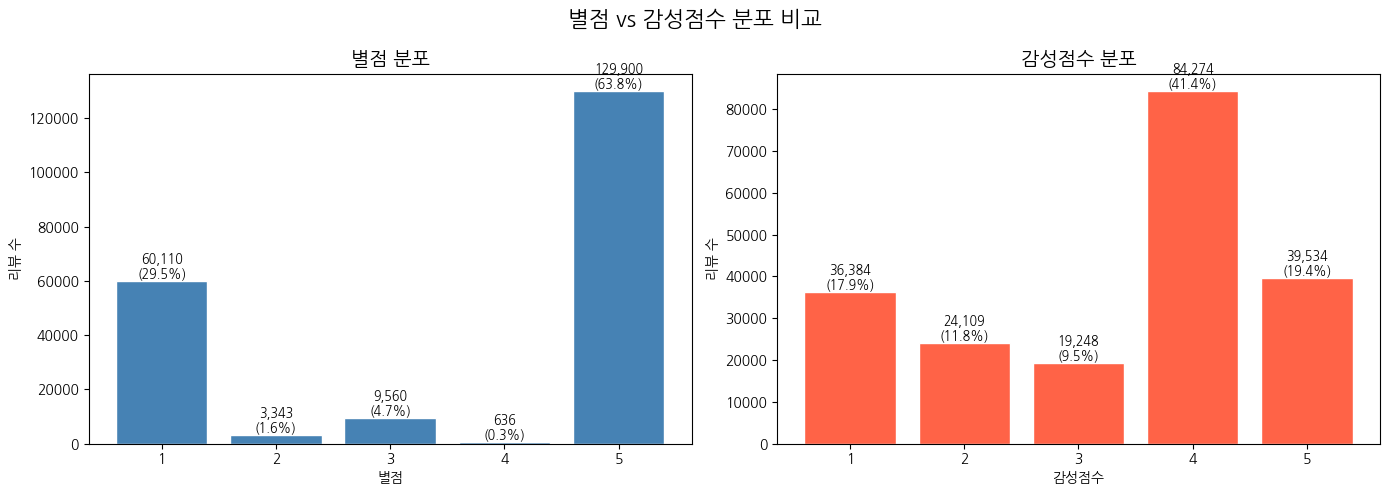

=== 별점 분포 ===
별점
1.0     60110
2.0      3343
3.0      9560
4.0       636
5.0    129900

5점 비율: 63.8%

=== 감성점수 분포 ===
감성점수
1    36384
2    24109
3    19248
4    84274
5    39534

4-5점(긍정) 비율: 60.8%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 별점 분포
star_counts = bot['별점'].value_counts().sort_index()
axes[0].bar(star_counts.index, star_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('별점 분포', fontsize=14)
axes[0].set_xlabel('별점')
axes[0].set_ylabel('리뷰 수')
for x, y in zip(star_counts.index, star_counts.values):
    axes[0].text(x, y, f'{y:,}\n({y/len(bot)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

# 감성점수 분포
sent_counts = bot['감성점수'].value_counts().sort_index()
axes[1].bar(sent_counts.index, sent_counts.values, color='tomato', edgecolor='white')
axes[1].set_title('감성점수 분포', fontsize=14)
axes[1].set_xlabel('감성점수')
axes[1].set_ylabel('리뷰 수')
for x, y in zip(sent_counts.index, sent_counts.values):
    axes[1].text(x, y, f'{y:,}\n({y/len(bot)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.suptitle('별점 vs 감성점수 분포 비교', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 수치 요약
print('=== 별점 분포 ===')
print(star_counts.to_string())
print(f'\n5점 비율: {(bot["별점"]==5).sum()/len(bot)*100:.1f}%')

print('\n=== 감성점수 분포 ===')
print(sent_counts.to_string())
print(f'\n4-5점(긍정) 비율: {(bot["감성점수"]>=4).sum()/len(bot)*100:.1f}%')

### 해석
**별점 분포 — 극단적 양극화**
- 5점 63.8%, 1점 29.5%로 중간값(2~4점) 합계가 **6.6%**에 불과
- 전형적인 J커브 형태 → 소비자가 별점을 "만족/불만족" 이분법으로만 사용하는 경향

**감성점수 분포 — 상대적으로 고른 분포**
- 1-3점(부정) 합계 39.2%, 4-5점(긍정) 합계 60.8%
- 중간 구간(2~3점)에 **33,357건(16.4%)** 존재 → 별점에서 포착되지 않던 중립/복합 감성 반영

### 핵심 메시지

| 구분 | 별점 | 감성점수 |
|---|---|---|
| 분포 형태 | J커브 (양극화) | 완만한 우편향 분포 |
| 중간값 비율 | 6.6% | 16.4% |
| 감성 세분화 | 불가 | 가능 |

**→ 별점만으로는 실제 소비자 감성의 세부 스펙트럼을 포착할 수 없음. 감성점수 도입을 통해 중립·복합 감성 리뷰를 별도 식별하는 것이 분석의 정확도를 높임.**

## 2. 브랜드별 소비자 반응 프로파일 레이더맵

In [ ]:
# [한글폰트 설치 - Colab]
import pandas as pd
import numpy as np

# Install Korean font
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# Configure Matplotlib to use NanumGothic
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # To prevent breaking minus sign

In [ ]:
# 컬리 PB 상품들 필터링
pb_brands = ['KF365', "kurly's", '차려낸']
pb_df = 제품df1[제품df1['브랜드'].isin(pb_brands)].copy()
곰곰_df = 제품df1[제품df1['브랜드'] == '곰곰'].copy()

# 컬리 PB 내에서 4구간화
pb_df['리뷰활성도'] = pd.qcut(pb_df['리뷰수'], q=4, labels=[1, 2, 3, 4]).astype(int)

# 곰곰 내에서 4구간화
곰곰_df['리뷰활성도'] = pd.qcut(곰곰_df['리뷰수'], q=4, labels=[1, 2, 3, 4]).astype(int)

# 브랜드별 평균 구간값 산출
pb_활성도 = pb_df.groupby('브랜드')['리뷰활성도'].mean().reset_index()
곰곰_활성도 = 곰곰_df.groupby('브랜드')['리뷰활성도'].mean().reset_index()

활성도_df = pd.concat([pb_활성도, 곰곰_활성도], ignore_index=True)
print(활성도_df)

       브랜드     리뷰활성도
0    KF365  2.497653
1  kurly's  2.435484
2      차려낸  2.615385
3       곰곰  2.499246


In [ ]:
# ========================================
# 브랜드df 전체 생성 코드 (최종)
# ========================================

# 1. 브랜드 단위 집계
브랜드df = 제품df1.groupby('브랜드').apply(
    lambda x: pd.Series({
        '평균별점': np.average(x['평균별점'], weights=x['리뷰수']),
        '긍정리뷰비율': np.average(x['긍정리뷰비율'], weights=x['리뷰수']),
        '부정리뷰비율': np.average(x['부정리뷰비율'], weights=x['리뷰수']),
    }), include_groups=False
).reset_index()

# 2. 총리뷰수 추가
리뷰수합 = 제품df1.groupby('브랜드')['리뷰수'].sum().reset_index()
리뷰수합.columns = ['브랜드', '총리뷰수']
브랜드df = 브랜드df.merge(리뷰수합, on='브랜드')

# 3. 언급비율 추가
언급비율_df = 제품df1.groupby('브랜드').apply(
    lambda x: pd.Series({
        '품질언급비율': np.average(x['품질언급비율'], weights=x['리뷰수']),
        '가성비언급비율': np.average(x['가성비언급비율'], weights=x['리뷰수']),
        '배송언급비율': np.average(x['배송언급비율'], weights=x['리뷰수']),
    }), include_groups=False
).reset_index()
브랜드df = 브랜드df.merge(언급비율_df, on='브랜드')

# 4. std 추가
std_df = 제품df1.groupby('브랜드').agg(
    품질언급비율_std=('품질언급비율', 'std'),
    가성비언급비율_std=('가성비언급비율', 'std'),
    배송언급비율_std=('배송언급비율', 'std')
).reset_index()
브랜드df = 브랜드df.merge(std_df, on='브랜드')

# 5. 평균감성점수 추가
감성점수_df = bot.groupby('브랜드').apply(
    lambda x: pd.Series({
        '평균감성점수': np.average(x['감성점수'])
    }), include_groups=False
).reset_index()
브랜드df = 브랜드df.merge(감성점수_df, on='브랜드')

# 6. 상품수 + 상품당리뷰수 추가
상품수 = 제품df1.groupby('브랜드').size().reset_index()
상품수.columns = ['브랜드', '상품수']
브랜드df = 브랜드df.merge(상품수, on='브랜드')
브랜드df['상품당리뷰수'] = 브랜드df['총리뷰수'] / 브랜드df['상품수']

# 7. 품질/가성비/배송 긍정 비율 추가 (키워드 없음 제외)
def 긍정비율(brand_bot, category):
    valid = brand_bot[brand_bot[category] != '키워드 없음']
    pos = (valid['감성분류'] == '긍정').sum()
    total = len(valid)
    return (pos / total * 100) if total > 0 else 0

긍정비율_df = bot.groupby('브랜드').apply(
    lambda x: pd.Series({
        '품질긍정비율': 긍정비율(x, '품질'),
        '가성비긍정비율': 긍정비율(x, '구성/가성비'),
        '배송긍정비율': 긍정비율(x, '배송'),
    }), include_groups=False
).reset_index()
브랜드df = 브랜드df.merge(긍정비율_df, on='브랜드')

# 8. 리뷰활성도 구간화 (상품 수준)
pb_brands = ['KF365', "kurly's", '차려낸']
pb_df = 제품df1[제품df1['브랜드'].isin(pb_brands)].copy()
곰곰_df = 제품df1[제품df1['브랜드'] == '곰곰'].copy()

pb_df['리뷰활성도'] = pd.qcut(pb_df['리뷰수'], q=4, labels=[1, 2, 3, 4]).astype(int)
곰곰_df['리뷰활성도'] = pd.qcut(곰곰_df['리뷰수'], q=4, labels=[1, 2, 3, 4]).astype(int)

pb_활성도 = pb_df.groupby('브랜드')['리뷰활성도'].mean().reset_index()
곰곰_활성도 = 곰곰_df.groupby('브랜드')['리뷰활성도'].mean().reset_index()
활성도_df = pd.concat([pb_활성도, 곰곰_활성도], ignore_index=True)
브랜드df = 브랜드df.merge(활성도_df, on='브랜드')

print(브랜드df.columns.tolist())
print(브랜드df[['브랜드', '품질긍정비율', '가성비긍정비율', '배송긍정비율', '평균감성점수', '리뷰활성도']])

['브랜드', '평균별점', '긍정리뷰비율', '부정리뷰비율', '총리뷰수', '품질언급비율', '가성비언급비율', '배송언급비율', '품질언급비율_std', '가성비언급비율_std', '배송언급비율_std', '평균감성점수', '상품수', '상품당리뷰수', '품질긍정비율', '가성비긍정비율', '배송긍정비율', '리뷰활성도']
       브랜드     품질긍정비율    가성비긍정비율     배송긍정비율    평균감성점수     리뷰활성도
0    KF365  79.552996  85.998359  80.785423  3.798141  2.497653
1  kurly's  82.446424  88.177227  82.316344  3.870840  2.435484
2       곰곰  57.268971  74.505256  70.269073  3.184540  2.499246
3      차려낸  74.878181  83.281573  77.161215  3.705099  2.615385


In [ ]:
# 1~5점으로 선형 변환
브랜드df_final = 브랜드df[브랜드df['브랜드'].isin(target_brands)].copy()

브랜드df_final['품질긍정비율_scaled'] = (브랜드df_final['품질긍정비율'] / 100) * 4 + 1
브랜드df_final['가성비긍정비율_scaled'] = (브랜드df_final['가성비긍정비율'] / 100) * 4 + 1
브랜드df_final['배송긍정비율_scaled'] = (브랜드df_final['배송긍정비율'] / 100) * 4 + 1

print(브랜드df_final[['브랜드', '품질긍정비율_scaled', '가성비긍정비율_scaled', '배송긍정비율_scaled', '평균감성점수', '리뷰활성도']])

       브랜드  품질긍정비율_scaled  가성비긍정비율_scaled  배송긍정비율_scaled    평균감성점수     리뷰활성도
0    KF365       4.182120        4.439934       4.231417  3.798141  2.497653
1  kurly's       4.297857        4.527089       4.292654  3.870840  2.435484
2       곰곰       3.290759        3.980210       3.810763  3.184540  2.499246
3      차려낸       3.995127        4.331263       4.086449  3.705099  2.615385


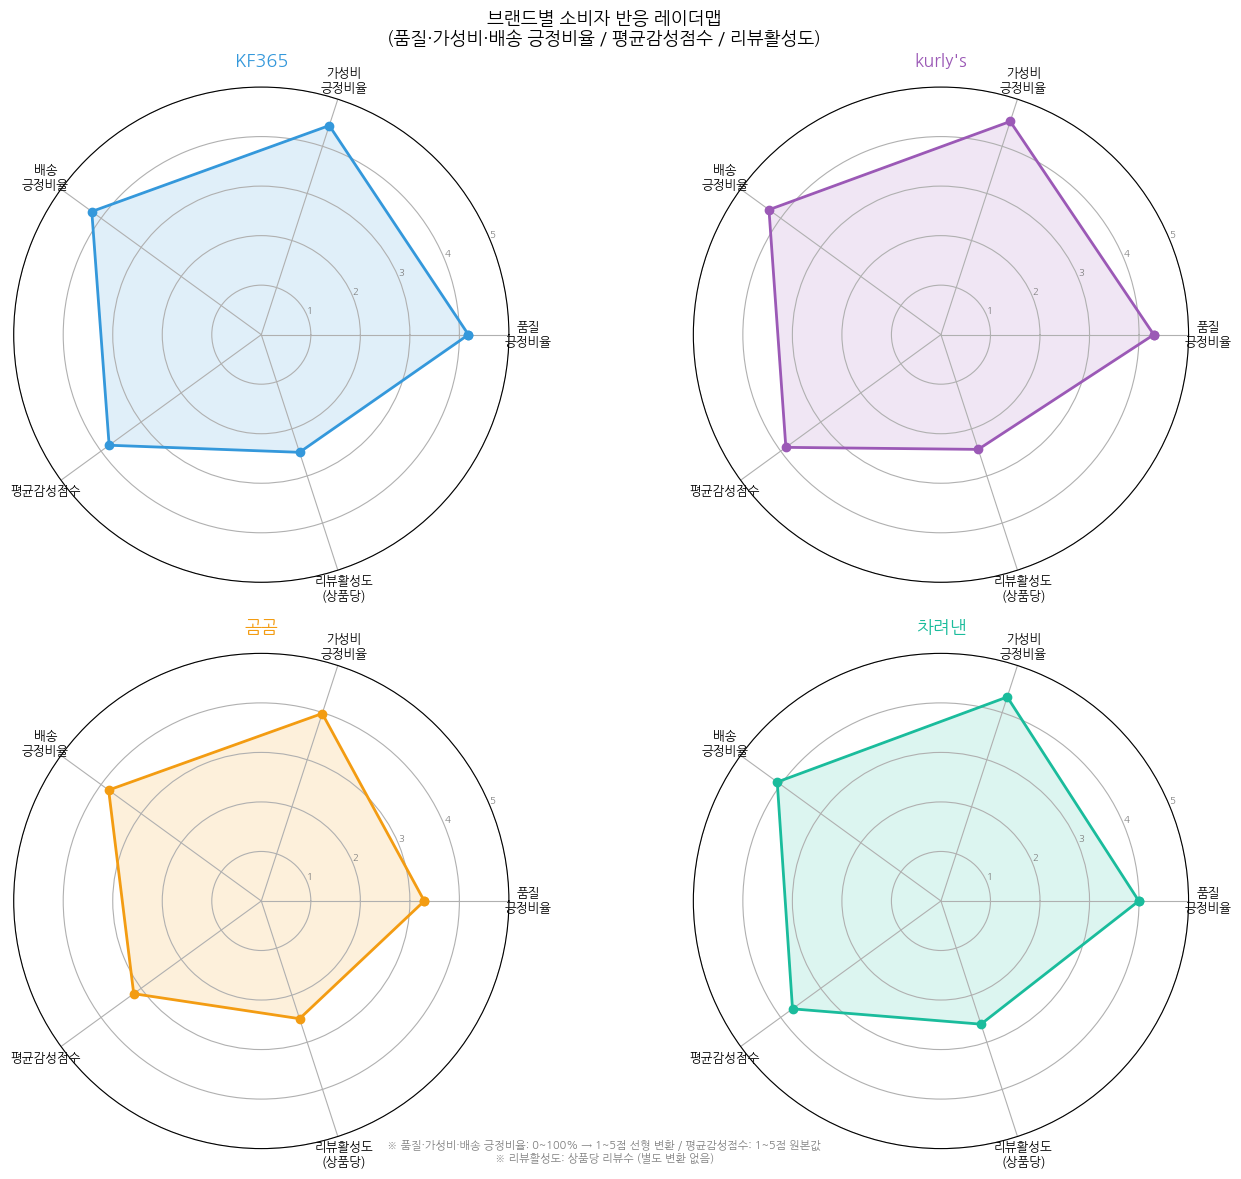

In [ ]:
categories_final = ['품질긍정비율_scaled', '가성비긍정비율_scaled', '배송긍정비율_scaled', '평균감성점수', '리뷰활성도']
labels_final = ['품질\n긍정비율', '가성비\n긍정비율', '배송\n긍정비율', '평균감성점수', '리뷰활성도\n(상품당)']
N = len(categories_final)
angles_final = [n / float(N) * 2 * np.pi for n in range(N)]
angles_final += angles_final[:1]

fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()

for idx, (_, row) in enumerate(브랜드df_final.iterrows()):
    ax = axes[idx]
    brand = row['브랜드']
    values = row[categories_final].tolist()
    values += values[:1]

    ax.plot(angles_final, values, 'o-', linewidth=2, color=colors[brand])
    ax.fill(angles_final, values, alpha=0.15, color=colors[brand])

    ax.set_xticks(angles_final[:-1])
    ax.set_xticklabels(labels_final, fontsize=9)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=7, color='grey')
    ax.set_ylim(0, 5)
    ax.set_title(brand, fontsize=13, fontweight='bold', pad=15, color=colors[brand])

fig.text(0.5, 0.02,
         '※ 품질·가성비·배송 긍정비율: 0~100% → 1~5점 선형 변환 / 평균감성점수: 1~5점 원본값\n'
         '※ 리뷰활성도: 상품당 리뷰수 (별도 변환 없음)',
         ha='center', fontsize=8, color='grey')

plt.suptitle('브랜드별 소비자 반응 레이더맵\n(품질·가성비·배송 긍정비율 / 평균감성점수 / 리뷰활성도)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

- 전체 브랜드 보기

In [ ]:
# 브랜드df 전체 6개 브랜드로 재생성
브랜드df = 제품df1.groupby('브랜드').apply(
    lambda x: pd.Series({
        '평균별점': np.average(x['평균별점'], weights=x['리뷰수']),
        '긍정리뷰비율': np.average(x['긍정리뷰비율'], weights=x['리뷰수']),
        '부정리뷰비율': np.average(x['부정리뷰비율'], weights=x['리뷰수']),
    }), include_groups=False
).reset_index()

리뷰수합 = 제품df1.groupby('브랜드')['리뷰수'].sum().reset_index()
리뷰수합.columns = ['브랜드', '총리뷰수']
브랜드df = 브랜드df.merge(리뷰수합, on='브랜드')

언급비율_df = 제품df1.groupby('브랜드').apply(
    lambda x: pd.Series({
        '품질언급비율': np.average(x['품질언급비율'], weights=x['리뷰수']),
        '가성비언급비율': np.average(x['가성비언급비율'], weights=x['리뷰수']),
        '배송언급비율': np.average(x['배송언급비율'], weights=x['리뷰수']),
    }), include_groups=False
).reset_index()
브랜드df = 브랜드df.merge(언급비율_df, on='브랜드')

std_df = 제품df1.groupby('브랜드').agg(
    품질언급비율_std=('품질언급비율', 'std'),
    가성비언급비율_std=('가성비언급비율', 'std'),
    배송언급비율_std=('배송언급비율', 'std')
).reset_index()
브랜드df = 브랜드df.merge(std_df, on='브랜드')

감성점수_df = bot.groupby('브랜드').apply(
    lambda x: pd.Series({
        '평균감성점수': np.average(x['감성점수'])
    }), include_groups=False
).reset_index()
브랜드df = 브랜드df.merge(감성점수_df, on='브랜드')

상품수 = 제품df1.groupby('브랜드').size().reset_index()
상품수.columns = ['브랜드', '상품수']
브랜드df = 브랜드df.merge(상품수, on='브랜드')
브랜드df['상품당리뷰수'] = 브랜드df['총리뷰수'] / 브랜드df['상품수']

# 긍정비율 추가 (전체 브랜드)
긍정비율_df = bot.groupby('브랜드').apply(
    lambda x: pd.Series({
        '품질긍정비율': 긍정비율_계산(x, '품질'),
        '가성비긍정비율': 긍정비율_계산(x, '구성/가성비'),
        '배송긍정비율': 긍정비율_계산(x, '배송'),
    }), include_groups=False
).reset_index()
브랜드df = 브랜드df.merge(긍정비율_df, on='브랜드')

print(브랜드df[['브랜드', '품질긍정비율', '가성비긍정비율', '배송긍정비율', '평균감성점수', '리뷰활성도']])

       브랜드     품질긍정비율    가성비긍정비율     배송긍정비율    평균감성점수     리뷰활성도
0    99시리즈  63.771840  75.675676  70.337302  3.419355  3.857143
1    KF365  79.552996  85.998359  80.785423  3.798141  2.469484
2  kurly's  82.446424  88.177227  82.316344  3.870840  2.435484
3       곰곰  57.268971  74.505256  70.269073  3.184540  2.499246
4    마이퍼스트  85.892116  86.800000  84.651163  3.923695  1.800000
5      차려낸  74.878181  83.281573  77.161215  3.705099  2.615385


In [ ]:
import numpy as np

# 브랜드df_all 생성
브랜드df_all = 브랜드df.copy()

# 긍정비율 1~5점 선형 변환
브랜드df_all['품질긍정비율_scaled'] = (브랜드df_all['품질긍정비율'] / 100) * 4 + 1
브랜드df_all['가성비긍정비율_scaled'] = (브랜드df_all['가성비긍정비율'] / 100) * 4 + 1
브랜드df_all['배송긍정비율_scaled'] = (브랜드df_all['배송긍정비율'] / 100) * 4 + 1

# 상품당리뷰수 로그변환 후 1~5점 선형 변환
log_리뷰 = np.log1p(브랜드df_all['상품당리뷰수'])
브랜드df_all['리뷰활성도_scaled'] = ((log_리뷰 - log_리뷰.min()) /
                                    (log_리뷰.max() - log_리뷰.min())) * 4 + 1

print(브랜드df_all[['브랜드', '품질긍정비율_scaled', '가성비긍정비율_scaled',
                   '배송긍정비율_scaled', '평균감성점수', '리뷰활성도_scaled']])

       브랜드  품질긍정비율_scaled  가성비긍정비율_scaled  배송긍정비율_scaled    평균감성점수  \
0    99시리즈       3.550874        4.027027       3.813492  3.419355   
1    KF365       4.182120        4.439934       4.231417  3.798141   
2  kurly's       4.297857        4.527089       4.292654  3.870840   
3       곰곰       3.290759        3.980210       3.810763  3.184540   
4    마이퍼스트       4.435685        4.472000       4.386047  3.923695   
5      차려낸       3.995127        4.331263       4.086449  3.705099   

   리뷰활성도_scaled  
0      4.148623  
1      2.238056  
2      2.328021  
3      5.000000  
4      1.000000  
5      2.684314  


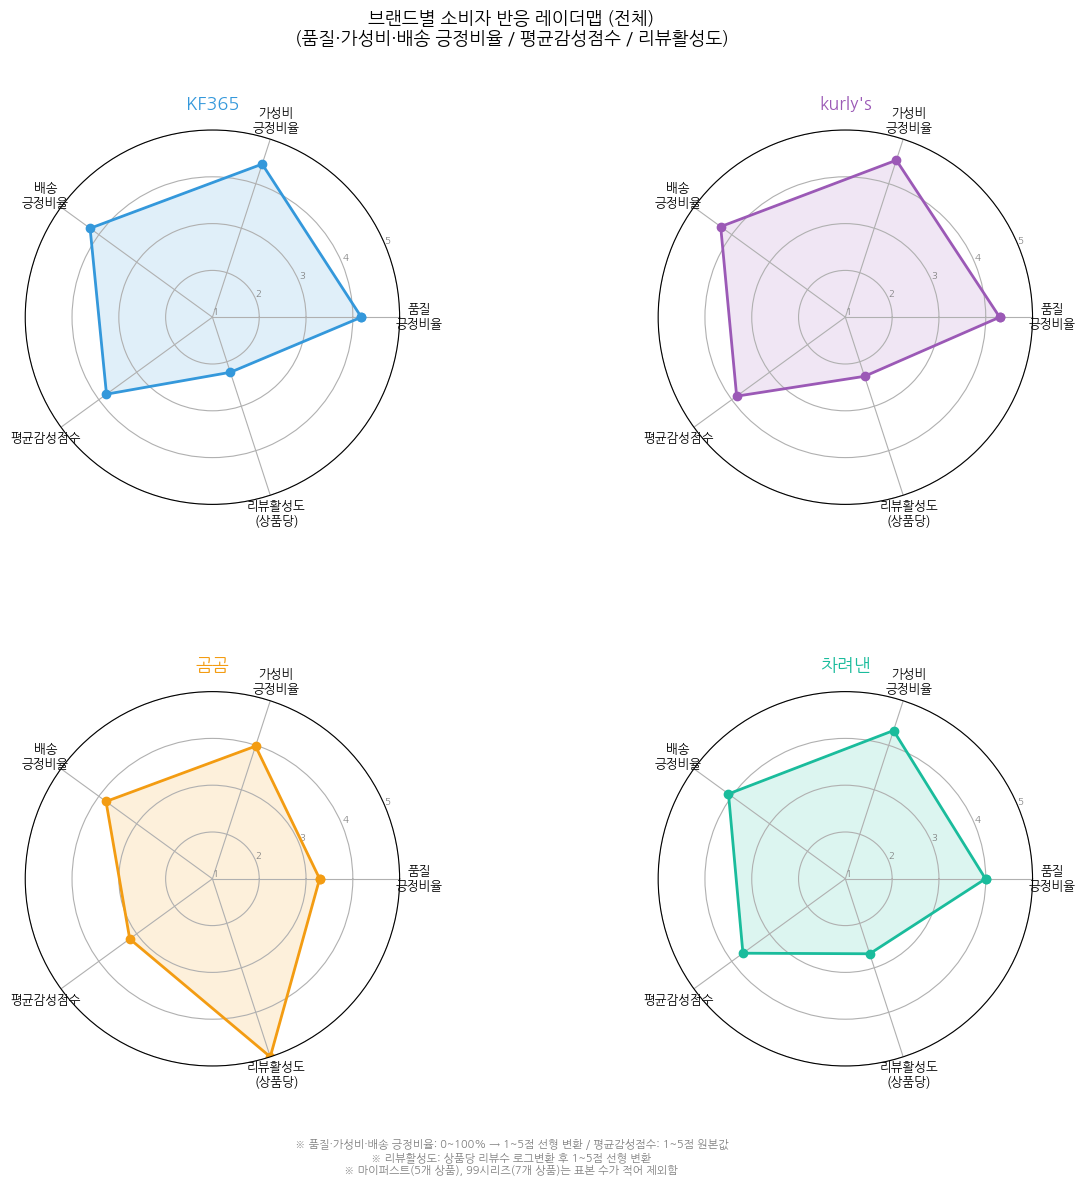

In [ ]:
categories_final = ['품질긍정비율_scaled', '가성비긍정비율_scaled', '배송긍정비율_scaled', '평균감성점수', '리뷰활성도_scaled']
labels_final = ['품질\n긍정비율', '가성비\n긍정비율', '배송\n긍정비율', '평균감성점수', '리뷰활성도\n(상품당)']
N = len(categories_final)
angles_final = [n / float(N) * 2 * np.pi for n in range(N)]
angles_final += angles_final[:1]

colors_all = {
    '99시리즈':  '#E74C3C',
    'KF365':    '#3498DB',
    "kurly's":  '#9B59B6',
    '곰곰':      '#F39C12',
    '마이퍼스트':  '#E67E22',
    '차려낸':    '#1ABC9C',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()

for idx, (_, row) in enumerate(브랜드df_all[~브랜드df_all['브랜드'].isin(['마이퍼스트', '99시리즈'])].iterrows()):
    ax = axes[idx]
    brand = row['브랜드']
    values = row[categories_final].tolist()
    values += values[:1]

    ax.plot(angles_final, values, 'o-', linewidth=2, color=colors_all[brand])
    ax.fill(angles_final, values, alpha=0.15, color=colors_all[brand])

    ax.set_xticks(angles_final[:-1])
    ax.set_xticklabels(labels_final, fontsize=9)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=7, color='grey')
    ax.set_ylim(1, 5)
    ax.set_title(brand, fontsize=13, fontweight='bold', pad=15, color=colors_all[brand])

fig.text(0.5, 0.01,
         '※ 품질·가성비·배송 긍정비율: 0~100% → 1~5점 선형 변환 / 평균감성점수: 1~5점 원본값\n'
         '※ 리뷰활성도: 상품당 리뷰수 로그변환 후 1~5점 선형 변환\n'
         '※ 마이퍼스트(5개 상품), 99시리즈(7개 상품)는 표본 수가 적어 제외함',
         ha='center', fontsize=8, color='grey')

plt.suptitle('브랜드별 소비자 반응 레이더맵 (전체)\n(품질·가성비·배송 긍정비율 / 평균감성점수 / 리뷰활성도)',
             fontsize=13, fontweight='bold')

plt.subplots_adjust(hspace=0.5, wspace=0.4, bottom=0.1)
plt.show()

## 3.브랜드별 소비자 반응 주제의 명확도 분석
- 언급비율: 전체 리뷰 중 '키워드 없음'이 아닌 리뷰 비율
- 긍정비율: '키워드 없음' 제외 후 긍정/(긍정+부정) × 100
- std: 상품별 언급비율(키워드 없음 제외)의 브랜드 내 표준편차

In [ ]:
# heatmap_df 생성
def 언급비율_계산(brand_bot, category):
    total = len(brand_bot)
    언급 = (brand_bot[category] != '키워드 없음').sum()
    return 언급 / total * 100 if total > 0 else 0

def 긍정비율_계산(brand_bot, category):
    valid = brand_bot[brand_bot[category] != '키워드 없음']
    pos = (valid['감성분류'] == '긍정').sum()
    total = len(valid)
    return pos / total * 100 if total > 0 else 0

heatmap_df = bot.groupby('브랜드').apply(
    lambda x: pd.Series({
        '품질언급비율': 언급비율_계산(x, '품질'),
        '가성비언급비율': 언급비율_계산(x, '구성/가성비'),
        '배송언급비율': 언급비율_계산(x, '배송'),
        '품질긍정비율': 긍정비율_계산(x, '품질'),
        '가성비긍정비율': 긍정비율_계산(x, '구성/가성비'),
        '배송긍정비율': 긍정비율_계산(x, '배송'),
    }), include_groups=False
).reset_index()

# 상품별 언급비율 산출 (키워드 없음 제외)
def 상품별언급비율(category):
    total = bot.groupby('상품ID')[category].count()
    언급 = bot[bot[category] != '키워드 없음'].groupby('상품ID')[category].count()
    비율 = (언급 / total * 100).fillna(0).reset_index()
    비율.columns = ['상품ID', f'{category}_언급비율']
    return 비율

품질_비율 = 상품별언급비율('품질')
가성비_비율 = 상품별언급비율('구성/가성비')
배송_비율 = 상품별언급비율('배송')

상품브랜드 = bot[['상품ID', '브랜드']].drop_duplicates()
품질_비율 = 품질_비율.merge(상품브랜드, on='상품ID')
가성비_비율 = 가성비_비율.merge(상품브랜드, on='상품ID')
배송_비율 = 배송_비율.merge(상품브랜드, on='상품ID')

std_new = pd.DataFrame({
    '브랜드': 품질_비율.groupby('브랜드')['품질_언급비율'].std().index,
    '품질언급비율_std': 품질_비율.groupby('브랜드')['품질_언급비율'].std().values,
    '가성비언급비율_std': 가성비_비율.groupby('브랜드')['구성/가성비_언급비율'].std().values,
    '배송언급비율_std': 배송_비율.groupby('브랜드')['배송_언급비율'].std().values,
})

heatmap_df = heatmap_df.merge(std_new, on='브랜드')

# 스케일 변환 (1~5점)
heatmap_df_scaled = heatmap_df.copy()

for col in ['품질언급비율', '가성비언급비율', '배송언급비율',
            '품질긍정비율', '가성비긍정비율', '배송긍정비율']:
    heatmap_df_scaled[col] = (heatmap_df_scaled[col] / 100) * 4 + 1

for col in ['품질언급비율_std', '가성비언급비율_std', '배송언급비율_std']:
    min_val = heatmap_df_scaled[col].min()
    max_val = heatmap_df_scaled[col].max()
    heatmap_df_scaled[col] = ((heatmap_df_scaled[col] - min_val) /
                               (max_val - min_val)) * 4 + 1

print(heatmap_df_scaled[['브랜드', '품질언급비율', '가성비언급비율', '배송언급비율',
                          '품질긍정비율', '가성비긍정비율', '배송긍정비율',
                          '품질언급비율_std', '가성비언급비율_std', '배송언급비율_std']])

       브랜드    품질언급비율   가성비언급비율    배송언급비율    품질긍정비율   가성비긍정비율    배송긍정비율  \
0    99시리즈  4.804497  3.097752  2.970674  3.550874  4.027027  3.813492   
1    KF365  4.783953  2.950082  2.959191  4.182120  4.439934  4.231417   
2  kurly's  4.747772  2.965482  2.885618  4.297857  4.527089  4.292654   
3       곰곰  4.828642  3.435972  3.261224  3.290759  3.980210  3.810763   
4    마이퍼스트  4.871486  3.008032  2.726908  4.435685  4.472000  4.386047   
5      차려낸  4.785806  2.980015  2.754548  3.995127  4.331263  4.086449   

   품질언급비율_std  가성비언급비율_std  배송언급비율_std  
0    1.000000     1.000000    1.000000  
1    2.133791     4.293755    3.424059  
2    3.195449     4.292135    5.000000  
3    1.889007     4.341698    3.038650  
4    1.519447     4.434117    2.668567  
5    5.000000     5.000000    4.164560  


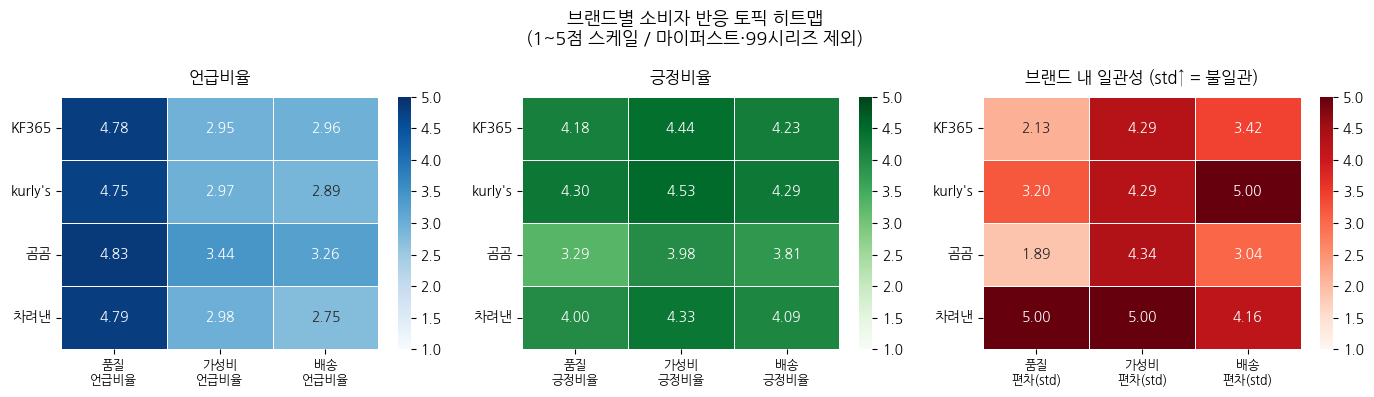

In [ ]:
# 마이퍼스트, 99시리즈 제외
heatmap_plot = heatmap_df_scaled[~heatmap_df_scaled['브랜드'].isin(['마이퍼스트', '99시리즈'])].set_index('브랜드')

col_order = ['품질언급비율', '가성비언급비율', '배송언급비율',
             '품질긍정비율', '가성비긍정비율', '배송긍정비율',
             '품질언급비율_std', '가성비언급비율_std', '배송언급비율_std']
col_labels = ['품질\n언급비율', '가성비\n언급비율', '배송\n언급비율',
              '품질\n긍정비율', '가성비\n긍정비율', '배송\n긍정비율',
              '품질\n편차(std)', '가성비\n편차(std)', '배송\n편차(std)']

heatmap_plot = heatmap_plot[col_order]
heatmap_plot.columns = col_labels

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

groups = {
    '언급비율': ['품질\n언급비율', '가성비\n언급비율', '배송\n언급비율'],
    '긍정비율': ['품질\n긍정비율', '가성비\n긍정비율', '배송\n긍정비율'],
    '브랜드 내 일관성 (std↑ = 불일관)': ['품질\n편차(std)', '가성비\n편차(std)', '배송\n편차(std)']
}
cmaps = ['Blues', 'Greens', 'Reds']

for ax, (title, cols), cmap in zip(axes, groups.items(), cmaps):
    sns.heatmap(heatmap_plot[cols], annot=True, fmt='.2f', cmap=cmap,
                linewidths=0.5, linecolor='white',
                vmin=1, vmax=5, ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, rotation=0)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=9)

plt.suptitle('브랜드별 소비자 반응 토픽 히트맵\n(1~5점 스케일 / 마이퍼스트·99시리즈 제외)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

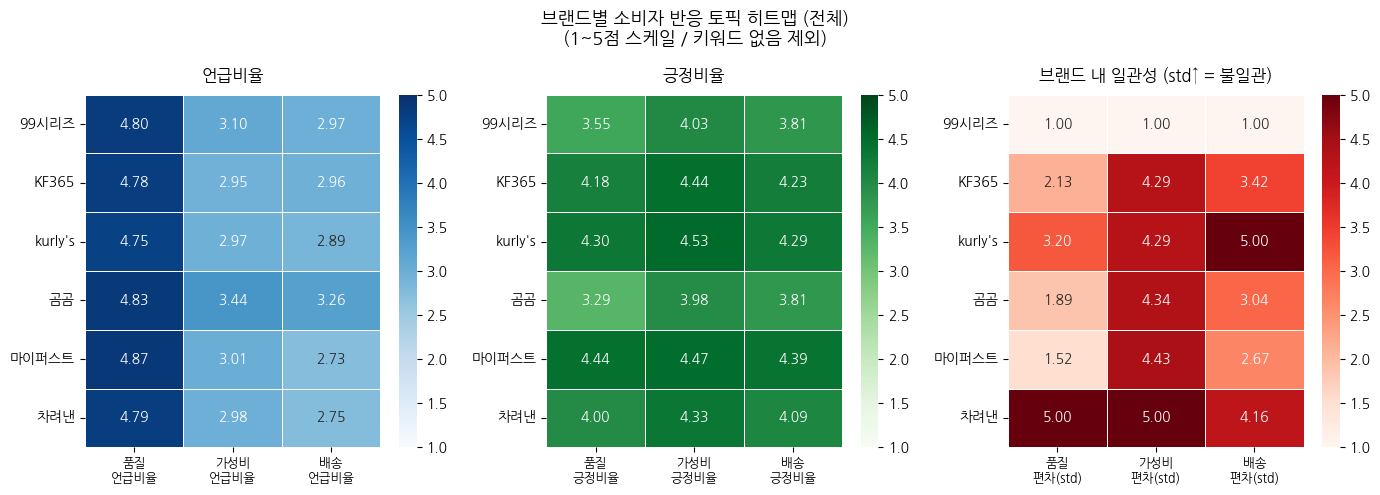

In [ ]:
# 전체 브랜드 히트맵 (마이퍼스트, 99시리즈 포함)
heatmap_plot_all = heatmap_df_scaled.set_index('브랜드')

col_order = ['품질언급비율', '가성비언급비율', '배송언급비율',
             '품질긍정비율', '가성비긍정비율', '배송긍정비율',
             '품질언급비율_std', '가성비언급비율_std', '배송언급비율_std']
col_labels = ['품질\n언급비율', '가성비\n언급비율', '배송\n언급비율',
              '품질\n긍정비율', '가성비\n긍정비율', '배송\n긍정비율',
              '품질\n편차(std)', '가성비\n편차(std)', '배송\n편차(std)']

heatmap_plot_all = heatmap_plot_all[col_order]
heatmap_plot_all.columns = col_labels

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

groups = {
    '언급비율': ['품질\n언급비율', '가성비\n언급비율', '배송\n언급비율'],
    '긍정비율': ['품질\n긍정비율', '가성비\n긍정비율', '배송\n긍정비율'],
    '브랜드 내 일관성 (std↑ = 불일관)': ['품질\n편차(std)', '가성비\n편차(std)', '배송\n편차(std)']
}
cmaps = ['Blues', 'Greens', 'Reds']

for ax, (title, cols), cmap in zip(axes, groups.items(), cmaps):
    sns.heatmap(heatmap_plot_all[cols], annot=True, fmt='.2f', cmap=cmap,
                linewidths=0.5, linecolor='white',
                vmin=1, vmax=5, ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, rotation=0)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=9)

plt.suptitle('브랜드별 소비자 반응 토픽 히트맵 (전체)\n(1~5점 스케일 / 키워드 없음 제외)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. 브랜드별 긍정/부정 리뷰의 카테고리(품질, 가성비, 배송)별 언급 비율

In [ ]:
# 히트맵 C 재산출 (키워드 없음 제외 / 마이퍼스트·99시리즈 제외)
target_brands_c = ['KF365', "kurly's", '곰곰', '차려낸']

def 감성별언급비율(brand_bot, category, sentiment):
    sentiment_bot = brand_bot[brand_bot['감성분류'] == sentiment]
    total = len(sentiment_bot)
    언급 = (sentiment_bot[category] != '키워드 없음').sum()
    return 언급 / total * 100 if total > 0 else 0

heatmap_c_df = bot[bot['브랜드'].isin(target_brands_c)].groupby('브랜드').apply(
    lambda x: pd.Series({
        '품질언급비율(긍정)': 감성별언급비율(x, '품질', '긍정'),
        '가성비언급비율(긍정)': 감성별언급비율(x, '구성/가성비', '긍정'),
        '배송언급비율(긍정)': 감성별언급비율(x, '배송', '긍정'),
        '품질언급비율(부정)': 감성별언급비율(x, '품질', '부정'),
        '가성비언급비율(부정)': 감성별언급비율(x, '구성/가성비', '부정'),
        '배송언급비율(부정)': 감성별언급비율(x, '배송', '부정'),
    }), include_groups=False
).reset_index()

# 1~5점 선형 변환
for col in heatmap_c_df.columns[1:]:
    heatmap_c_df[col] = (heatmap_c_df[col] / 100) * 4 + 1

print(heatmap_c_df)

       브랜드  품질언급비율(긍정)  가성비언급비율(긍정)  배송언급비율(긍정)  품질언급비율(부정)  가성비언급비율(부정)  \
0    KF365    4.856636     3.148569    3.027758    4.525452     2.244145   
1  kurly's    4.841795     3.154839    2.929874    4.361383     2.187320   
2       곰곰    4.936053     4.258037    3.852361    4.693557     2.402102   
3      차려낸    4.878023     3.255871    2.852086    4.535238     2.230476   

   배송언급비율(부정)  
0    2.715327  
1    2.703746  
2    2.517779  
3    2.489524  


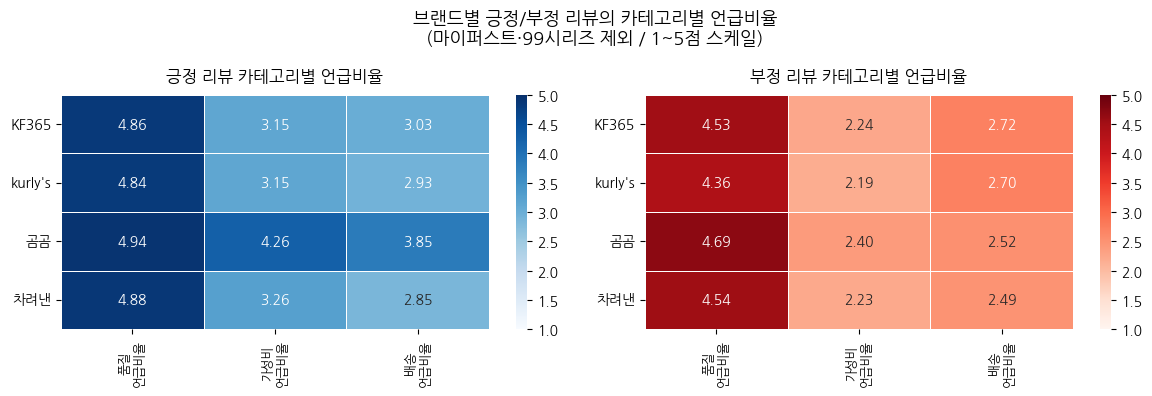

In [ ]:
heatmap_c_plot = heatmap_c_df.set_index('브랜드')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 긍정 리뷰 언급비율
sns.heatmap(heatmap_c_plot[['품질언급비율(긍정)', '가성비언급비율(긍정)', '배송언급비율(긍정)']],
            annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, linecolor='white',
            vmin=1, vmax=5, ax=axes[0])
axes[0].set_title('긍정 리뷰 카테고리별 언급비율', fontsize=12, fontweight='bold', pad=10)
axes[0].set_ylabel('')
axes[0].set_yticklabels(axes[0].get_yticklabels(), fontsize=10, rotation=0)
axes[0].set_xticklabels(['품질\n언급비율', '가성비\n언급비율', '배송\n언급비율'], fontsize=9)

# 부정 리뷰 언급비율
sns.heatmap(heatmap_c_plot[['품질언급비율(부정)', '가성비언급비율(부정)', '배송언급비율(부정)']],
            annot=True, fmt='.2f', cmap='Reds',
            linewidths=0.5, linecolor='white',
            vmin=1, vmax=5, ax=axes[1])
axes[1].set_title('부정 리뷰 카테고리별 언급비율', fontsize=12, fontweight='bold', pad=10)
axes[1].set_ylabel('')
axes[1].set_yticklabels(axes[1].get_yticklabels(), fontsize=10, rotation=0)
axes[1].set_xticklabels(['품질\n언급비율', '가성비\n언급비율', '배송\n언급비율'], fontsize=9)

plt.suptitle('브랜드별 긍정/부정 리뷰의 카테고리별 언급비율\n(마이퍼스트·99시리즈 제외 / 1~5점 스케일)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. 브랜드별 최빈 부정 키워드 분석

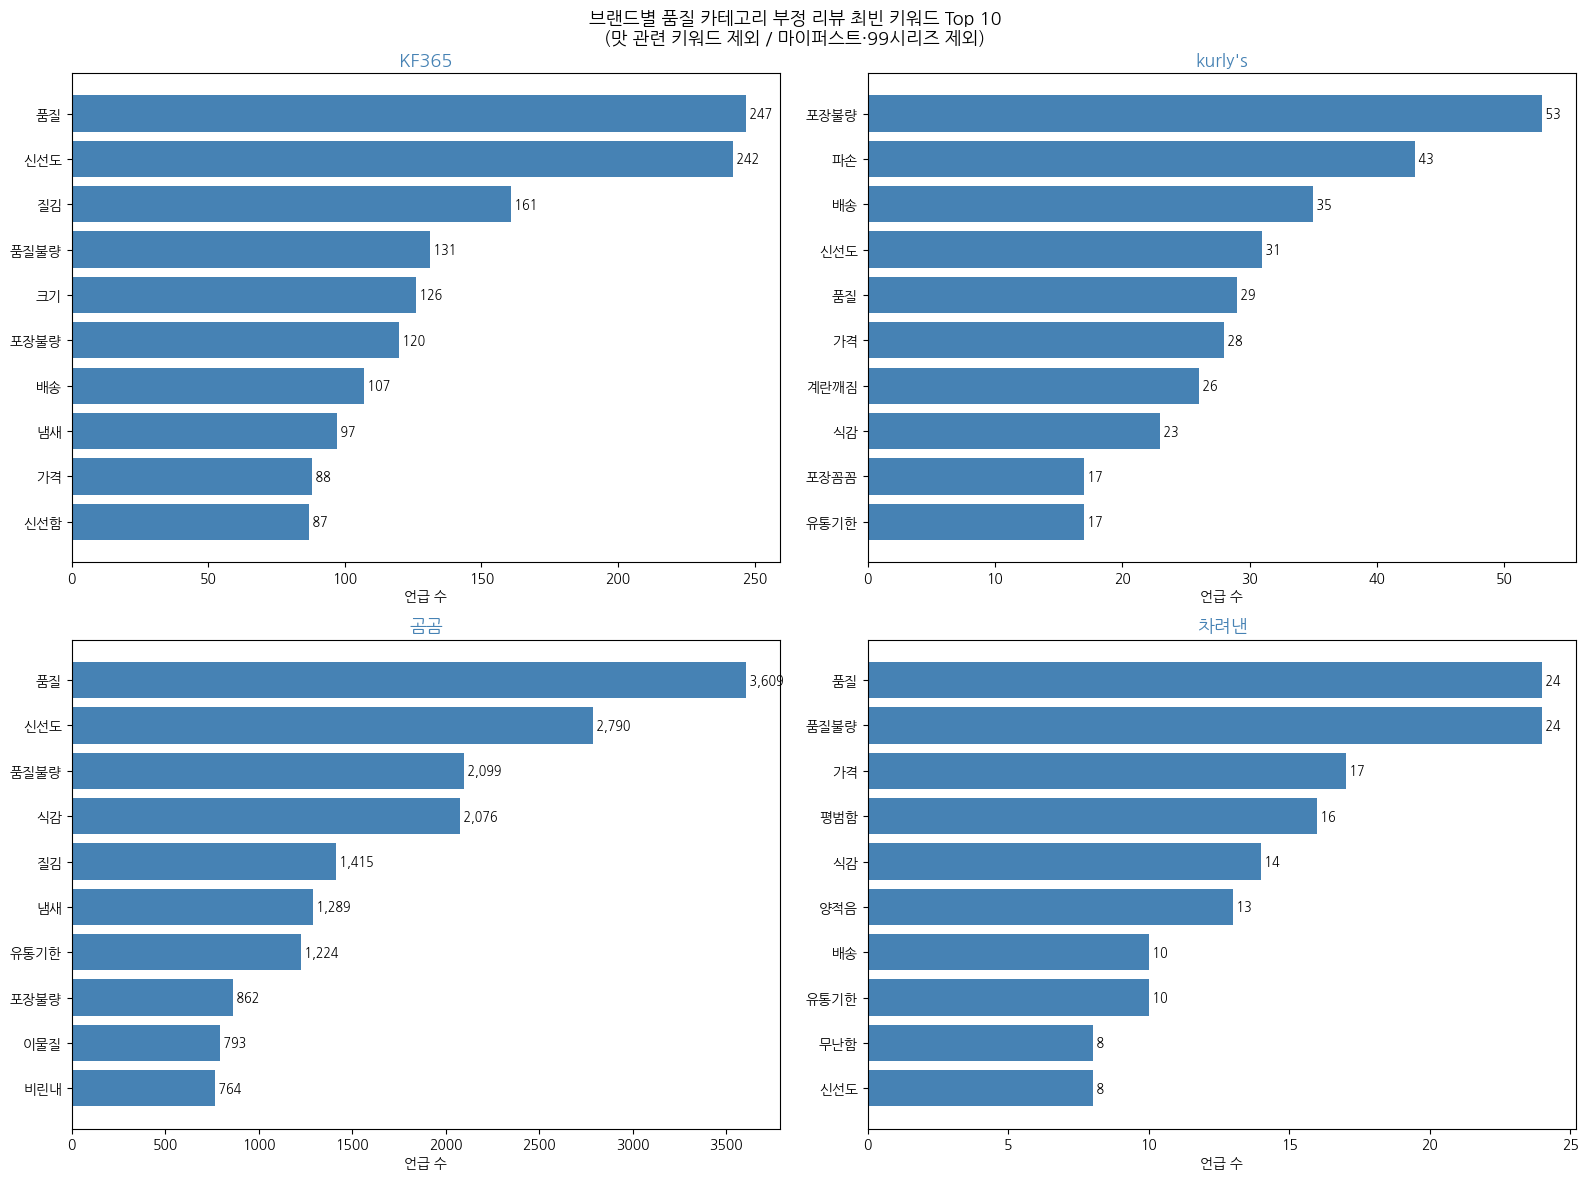

In [ ]:
# 품질 카테고리 부정 리뷰 최빈 키워드 분석 (맛 관련 제외)
target_brands_neg = ['KF365', "kurly's", '곰곰', '차려낸']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, brand in enumerate(target_brands_neg):
    ax = axes[idx]

    brand_neg = bot[
        (bot['브랜드'] == brand) &
        (bot['감성분류'] == '부정') &
        (bot['품질'] != '키워드 없음') &
        (~bot['품질'].str.contains('맛', na=False))
    ]

    top10 = brand_neg['품질'].value_counts().head(10)

    ax.barh(top10.index[::-1], top10.values[::-1], color='steelblue')
    ax.set_title(brand, fontsize=13, fontweight='bold', color='steelblue')
    ax.set_xlabel('언급 수')
    for i, v in enumerate(top10.values[::-1]):
        ax.text(v, i, f' {v:,}', va='center', fontsize=9)

plt.suptitle('브랜드별 품질 카테고리 부정 리뷰 최빈 키워드 Top 10\n(맛 관련 키워드 제외 / 마이퍼스트·99시리즈 제외)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
for brand in target_brands_neg:
    brand_neg = bot[
        (bot['브랜드'] == brand) &
        (bot['감성분류'] == '부정') &
        (bot['품질'] != '키워드 없음') &
        (~bot['품질'].str.contains('맛', na=False))
    ]

    print(f'\n=== {brand} ===')
    print(brand_neg['품질'].value_counts().to_string())

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
신선도               31
품질                29
가격                28
계란깨짐              26
식감                23
포장꼼꼼              17
유통기한              17
크기                16
가성비               16
양적음               16
깨짐                15
계란파손              15
무난함               13
평범                13
계란                12
배송파손              10
신선                10
질김                10
두부                 9
배송불량               9
배송빠름               8
포장                 8
냄새                 7
평범함                7
배송불만               7
난각번호               6
배송문제               6
사이즈                6
용량                 6
상품파손               6
편의성                5
알크기                5
양이적음               5
신선함                5
비린내                5
건강                 5
껍질까기어려움            5
이물질                4
보통                 4
기대                 4
누린내                4
퍽퍽함                4
양많음                4
계란크기               3
식감별로               3
양                  